### Learn to predict the bounding box



This notebook requires that you have downloaded the Thoracic organ at risk component of the struct seg dataset and placed it in a folder with the relative location of './data/ThoracicOAR'.

The data is available from https://structseg2019.grand-challenge.org/Dataset/

Let's take a look at the data. Start by loading an image slice.


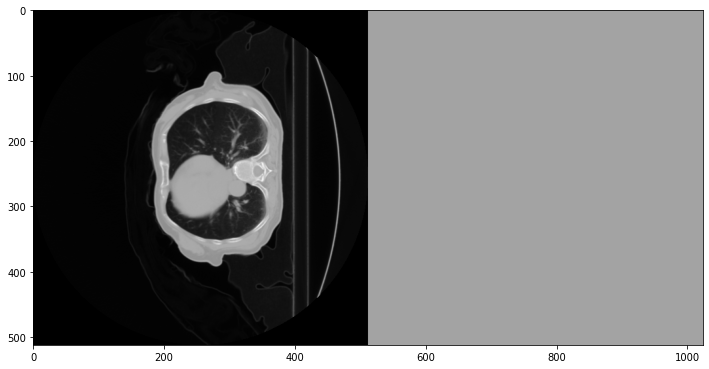

In [27]:
import os
import numpy as np
import nibabel as nib
from matplotlib.pyplot import imshow
import matplotlib.pyplot as plt

DATA_DIR = os.path.join('data', 'ThoracicOAR')

def load_nifty(image_path):
    """ load compressed nifty file from disk and
        switch first and last channel
    """
    image = nib.load(image_path)
    image = np.array(image.dataobj)
    image = np.moveaxis(image, -1, 0) # depth moved to beginning
    return image


def load_im_and_heart(data_dir, filter_labels=True):
    """ Load a heart from the struct seg data.
        Include binary (0,1) labels for the voxels which contain the heart.
    """
    image = load_nifty(os.path.join(data_dir, 'data.nii.gz'))
    annot = load_nifty(os.path.join(data_dir, 'label.nii.gz'))

    if filter_labels:
        heart_labels = (annot == 3).astype(np.int16) # only heart
        return image, heart_labels

    return image, annot.astype(np.int16)



def show_first_image_and_labels(im_dir_name = '1'):
    im_data_dir = os.path.join(DATA_DIR, im_dir_name)
    assert os.path.isdir(im_data_dir), f'{im_data_dir} required. Did you download struct seg?'
    
    # get data and heart labels for a patch with the heart in it
    image_data, heart_labels = load_im_and_heart(im_data_dir)

    # print('im shape', image_data.shape)
    # print('heart shape', heart_labels.shape)
    # lets show a slice with some labels.
    
    # Which slices contain heart?
    with_heart = [y for y in range(heart_labels.shape[0]) if np.any(heart_labels[y])]
    central_slice_idx = with_heart[len(with_heart)//2]
    central_slice_im = image_data[central_slice_idx]
    central_slice_labels = heart_labels[central_slice_idx]
                  
    im_for_show = np.hstack((central_slice_im, central_slice_labels))
    plt.figure(figsize=(12,12))
    imshow(im_for_show, cmap='gray')

show_first_image_and_labels()
